# Libraries

In [1]:
from functions import *
from UQpy.distributions import Normal, JointIndependent
# Do you want plot with latex font format? Use the cell bellow:
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import seaborn as sns
import numpy as np

d:\Documentos\ic_victor\myenv\Lib\site-packages\UQpy\__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Dataset

### General data

In [8]:
n_latent_samples = 2000
n_samples = 1000
r = Normal(loc = 4.715, scale=0.8)
s = Normal(loc = 1.770, scale=0.6) 

### State limit function $t$ = 0

In [9]:
step_time_0 = 0.0
divs = 10

In [10]:
joint = JointIndependent(marginals=[r, s])
x_val = joint.rvs(n_samples)
submatrices = np.array_split(x_val, divs)
df_0, glam_data_0 = g_toy_problem_parallel_with_multiprocessing(submatrices, n_latent_samples, t=step_time_0)
glam_data_0

,r,s,lambda 1,lambda 2,lambda 3,lambda 4
0,4.299285,1.207616,3.103680,9.261259,0.068817,0.130296
1,4.222411,1.760620,2.475449,7.523831,0.075263,0.141480
2,7.069127,1.306882,5.773144,6.212291,0.112676,0.146145
3,4.064806,0.955917,3.113258,9.983019,0.133119,0.149700
4,4.503190,1.135872,3.374418,8.406338,0.122083,0.136607
...,...,...,...,...,...,...
995,5.076103,1.318397,3.770977,7.660507,0.139622,0.149208
996,5.697317,1.498963,4.201677,6.938338,0.131544,0.129920
997,6.105801,1.597724,4.520031,6.464983,0.110837,0.143973
998,4.398549,2.508887,1.894101,5.397293,0.123646,0.159685


### State limit function $t$ = 50

In [11]:
step_time_50 = 100.0
divs = 10

In [12]:
joint = JointIndependent(marginals=[r, s])
x_val = joint.rvs(n_samples)
submatrices = np.array_split(x_val, divs)
df_50, glam_data_50 = g_toy_problem_parallel_with_multiprocessing(submatrices, n_latent_samples, t=step_time_50)
glam_data_50

,r,s,lambda 1,lambda 2,lambda 3,lambda 4
0,5.336074,1.696259,-0.079791,8.763557,0.047288,0.183659
1,4.700534,1.548397,-0.129909,10.159737,0.051421,0.158148
2,4.514951,2.564918,-1.193960,5.733212,0.069125,0.212214
3,4.811268,1.790457,-0.341919,8.217244,0.100758,0.141750
4,4.311104,1.716224,-0.412770,8.606496,0.069686,0.213649
...,...,...,...,...,...,...
995,5.113248,1.331567,0.209468,9.987928,0.155386,0.217569
996,5.578538,2.596108,-0.905202,6.016667,0.060759,0.171334
997,4.401332,1.993732,-0.657691,7.740215,0.077322,0.164890
998,4.743314,1.408973,0.023534,10.144927,0.076238,0.202590


# Charts

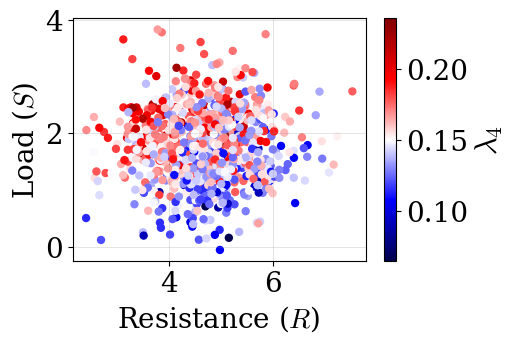

In [22]:
### Figure name and DPI
dpi = 600
name = 'lambda_4_t-0'

### Chart dimensions (in centimeters)
b_cm = 12
h_cm = 8
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels
label_x = 'Resistance ($R$)'
label_y = 'Load ($S$)'
label_cmap = r'$\lambda_{4}$'

size_label = 20
size_axis = 20

# 🔹 tamanhos específicos da colorbar
size_cbar_label = 22
size_cbar_ticks = 20

color_label = 'black'
color_axis = 'black'

### Scatter
cmap_type = 'seismic'
size_scatter = 25

### Grid
on_or_off = True
line_width_grid = 0.5
alpha_grid = 0.3
style_grid = '-'
color_grid = 'gray'

### Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))

ax.tick_params(axis='both', which='major',
               labelsize=size_axis,
               colors=color_axis)

ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

### Grid
ax.grid(on_or_off, which='both',
        linestyle=style_grid,
        linewidth=line_width_grid,
        color=color_grid,
        alpha=alpha_grid)

### Scatter plot
sc = ax.scatter(
    glam_data_0['r'],
    glam_data_0['s'],
    c=glam_data_0['lambda 4'],
    cmap=cmap_type,
    s=size_scatter
)

### Colorbar (AJUSTE PRINCIPAL)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(label_cmap,
               fontsize=size_cbar_label,
               color=color_label)

cbar.ax.tick_params(labelsize=size_cbar_ticks)

### Save
fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()


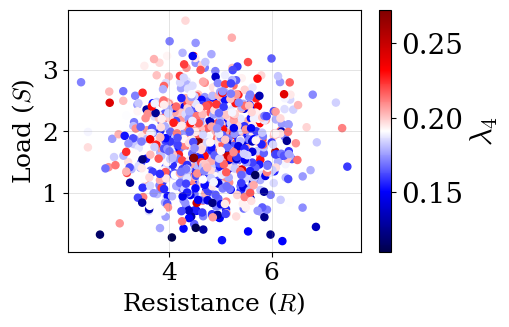

In [21]:
### Figure name and DPI
dpi = 600
name = 'lambda_4_t-50'

### Chart dimensions (in centimeters)
b_cm = 12
h_cm = 8
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels
label_x = 'Resistance ($R$)'
label_y = 'Load ($S$)'
label_cmap = r'$\lambda_{4}$'

size_label = 18
size_axis = 18

# 🔹 tamanhos específicos da colorbar (iguais ao t=0)
size_cbar_label = 22
size_cbar_ticks = 20

color_label = 'black'
color_axis = 'black'

### Scatter
cmap_type = 'seismic'
size_scatter = 26

### Grid
on_or_off = True
line_width_grid = 0.5
alpha_grid = 0.3
style_grid = '-'
color_grid = 'gray'

### Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))

ax.tick_params(axis='both', which='major',
               labelsize=size_axis,
               colors=color_axis)

ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

### Grid
ax.grid(on_or_off, which='both',
        linestyle=style_grid,
        linewidth=line_width_grid,
        color=color_grid,
        alpha=alpha_grid)

### Scatter plot
sc = ax.scatter(
    glam_data_50['r'],
    glam_data_50['s'],
    c=glam_data_50['lambda 4'],
    cmap=cmap_type,
    s=size_scatter
)

### Colorbar (AJUSTE PRINCIPAL)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(label_cmap,
               fontsize=size_cbar_label,
               color=color_label)

cbar.ax.tick_params(labelsize=size_cbar_ticks)

### Save
fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()
